# 华润江中 (600750) 股票数据分析

数据来源：Tushare Pro MCP 接口  
时间范围：2025-06-30 至 2026-06-26（241 个交易日）  

本 Notebook 演示以下流程：
1. 通过 Tushare API 获取 A 股日线行情
2. 数据清洗与预处理
3. K 线图绘制
4. 成交量分析
5. 统计摘要

## 1. 环境准备

安装依赖（如果尚未安装）：
```bash
pip install tushare pandas mplfinance numpy matplotlib
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

## 2. 数据获取

### 方法一：通过 Tushare Pro API 直接获取（需要 Tushare Token）

```python
import tushare as ts
ts.set_token('your_tushare_token_here')
pro = ts.pro_api()
df = pro.daily(ts_code='600750.SH', start_date='20250628', end_date='20260628')
df.to_csv('600750_daily.csv', index=False)
```

### 方法二：加载本地 CSV（已通过 MCP 接口获取并保存）

In [2]:
df = pd.read_csv('600750_daily.csv')
print(f"rows: {df.shape[0]}, cols: {df.shape[1]}")
print(f"columns: {list(df.columns)}")
df.head(8)

rows: 241, cols: 11
columns: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount
0,600750.SH,20260626,22.94,22.95,22.38,22.42,22.61,-0.19,-0.8403,25365.21,57188.232
1,600750.SH,20260625,22.98,23.20,22.53,22.61,23.09,-0.48,-2.0788,28940.34,65862.987
2,600750.SH,20260624,23.99,24.20,23.04,23.09,23.79,-0.70,-2.9424,46357.72,108973.063
3,600750.SH,20260623,23.53,23.94,23.23,23.79,23.35,0.44,1.8844,34042.20,80492.499
4,600750.SH,20260622,23.30,23.45,22.65,23.35,23.43,-0.08,-0.3414,47218.56,108852.093
5,600750.SH,20260618,24.36,24.47,24.16,24.31,24.26,0.05,0.2061,32010.75,77812.774
6,600750.SH,20260617,24.30,24.35,23.91,24.26,24.23,0.03,0.1238,29710.63,71922.653
7,600750.SH,20260616,24.46,24.73,24.10,24.23,24.70,-0.47,-1.9028,44324.20,107928.052


## 3. 数据预处理

In [3]:
df['date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df = df.sort_values('date').reset_index(drop=True)

df['is_up'] = df['close'] >= df['open']
df['range'] = df['high'] - df['low']

print(f"date range: {df['date'].iloc[0].date()} ~ {df['date'].iloc[-1].date()}")
print(f"trading days: {len(df)}")
df[['date', 'open', 'high', 'low', 'close', 'vol', 'pct_chg']].head()

date range: 2025-06-30 ~ 2026-06-26
trading days: 241


,date,open,high,low,close,vol,pct_chg
0,2025-06-30,21.92,21.99,21.78,21.83,38656.20,-0.3651
1,2025-07-01,21.83,21.90,21.75,21.83,37937.60,0.0000
2,2025-07-02,21.87,21.96,21.77,21.86,37542.50,0.1374
3,2025-07-03,21.90,22.15,21.86,21.98,60048.97,0.5489
4,2025-07-04,21.98,22.02,21.90,21.99,37063.13,0.0455


## 4. 统计摘要

In [4]:
stats = {
    'open_price': df['close'].iloc[0],
    'close_price': df['close'].iloc[-1],
    'total_change_pct': round((df['close'].iloc[-1] / df['close'].iloc[0] - 1) * 100, 2),
    'max_high': df['high'].max(),
    'min_low': df['low'].min(),
    'max_daily_gain_pct': round(df['pct_chg'].max(), 2),
    'max_daily_loss_pct': round(df['pct_chg'].min(), 2),
    'avg_volume': round(df['vol'].mean(), 0),
    'total_amount_billion': round(df['amount'].sum() / 1e8, 2),
}
for k, v in stats.items():
    print(f"{k}: {v}")

open_price: 21.83
close_price: 22.42
total_change_pct: 2.7
max_high: 27.83
min_low: 21.05
max_daily_gain_pct: 6.14
max_daily_loss_pct: -10.0
avg_volume: 58321.0
total_amount_billion: 0.33


## 5. K线图（mplfinance）

中国习惯：涨红跌绿

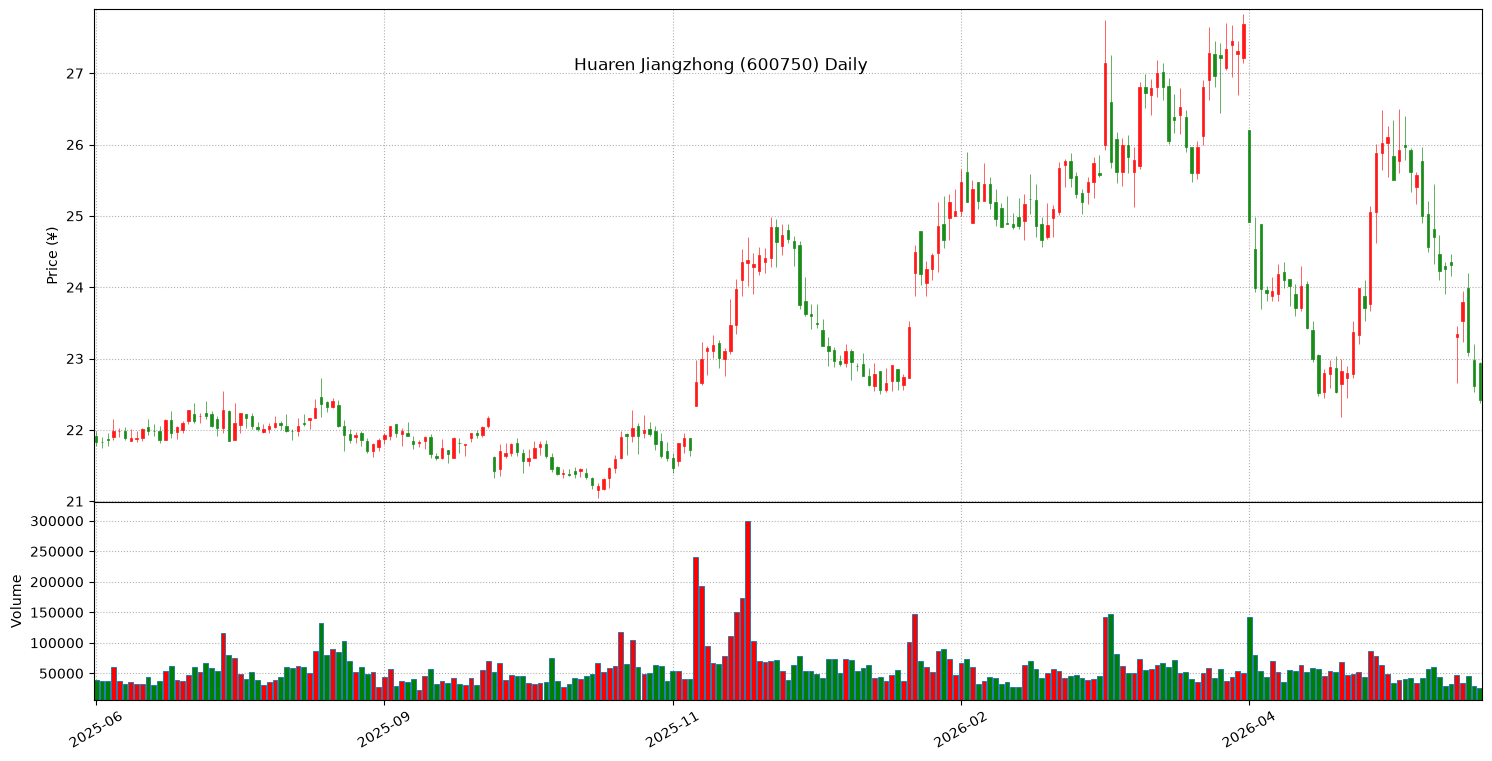

In [5]:
import mplfinance as mpf

df_mpf = df.set_index('date')[['open', 'high', 'low', 'close', 'vol']].copy()
df_mpf.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

mc = mpf.make_marketcolors(up='red', down='green', edge='inherit', wick='inherit',
    volume={'up': 'red', 'down': 'green'})
s = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False)

mpf.plot(df_mpf, type='candle', style=s, volume=True,
    title='Huaren Jiangzhong (600750) Daily',
    ylabel='Price (¥)', ylabel_lower='Volume',
    figsize=(16, 8), datetime_format='%Y-%m', xrotation=30, tight_layout=True)
plt.show()

## 5.1 Matplotlib 手绘 K线 + 均线（无需mplfinance）

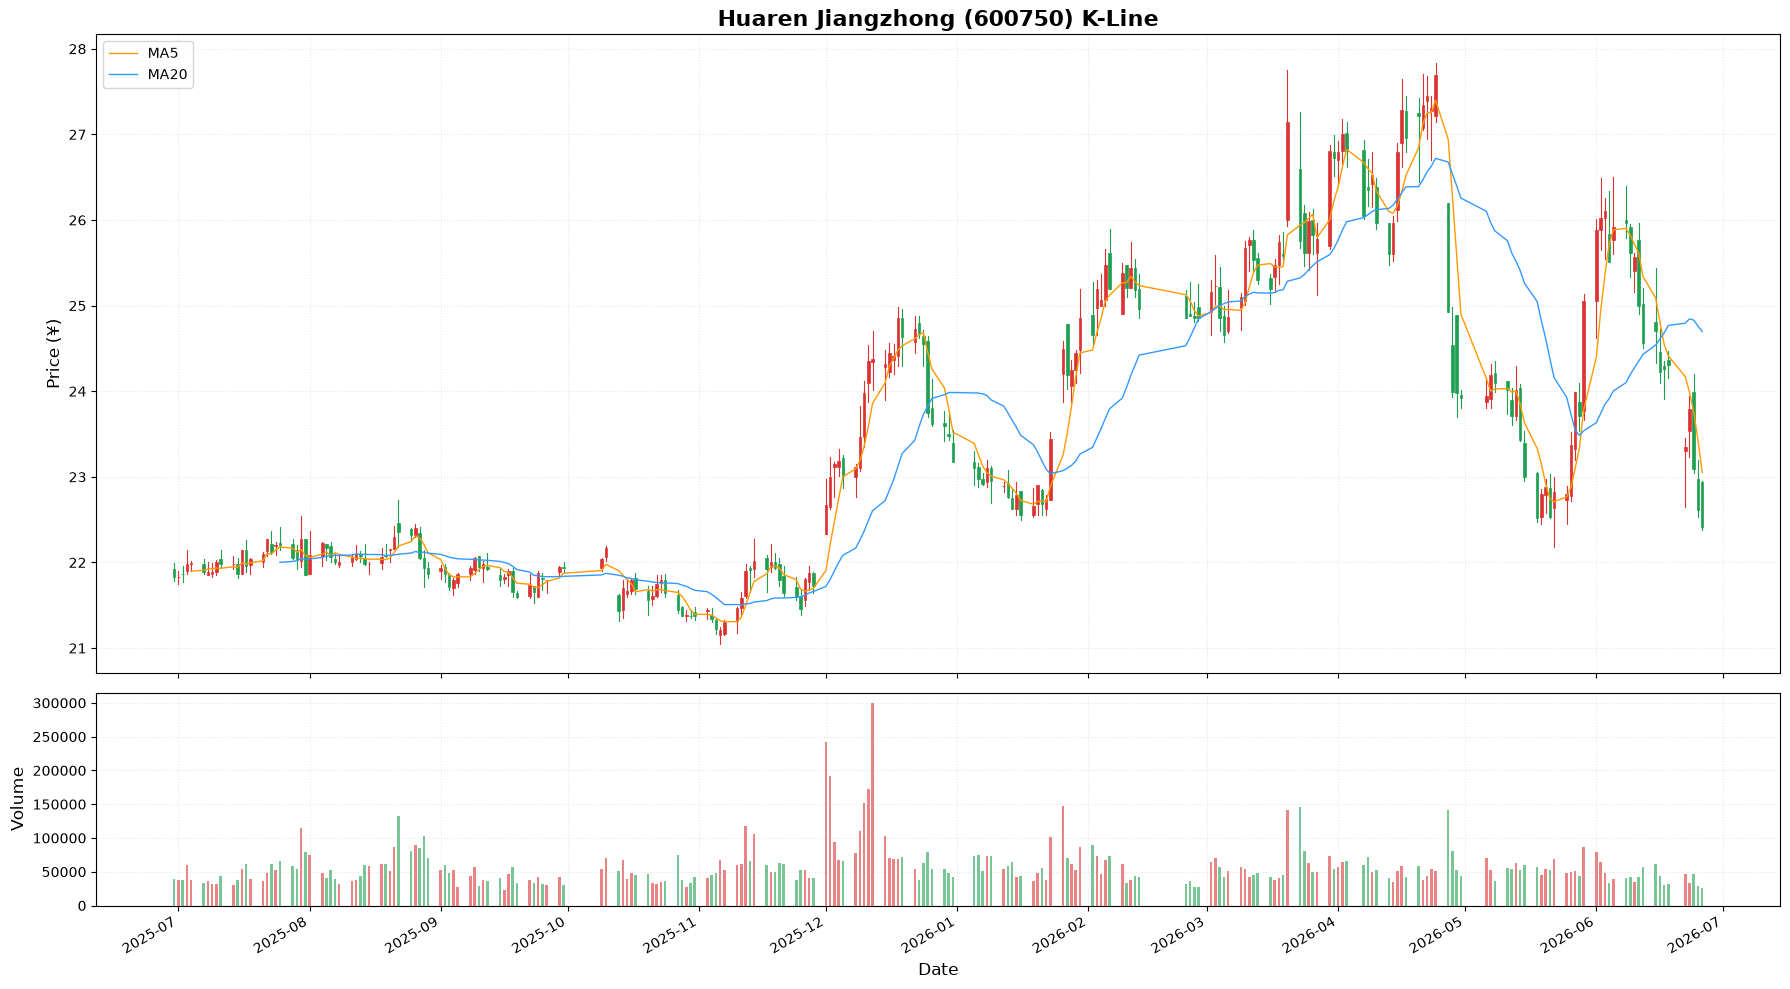

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 10),
    gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

width = 0.6
for i, row in df.iterrows():
    color = '#dc3232' if row['is_up'] else '#1ea050'
    idx = row['date']
    body_b = min(row['open'], row['close'])
    body_h = abs(row['close'] - row['open'])
    ax1.bar(idx, body_h, width=width, bottom=body_b, color=color, ec=color, lw=0.5)
    ax1.plot([idx, idx], [row['low'], row['high']], color=color, lw=0.8)
    ax2.bar(idx, row['vol'], width=width, color=color, alpha=0.6)

df['ma5'] = df['close'].rolling(5).mean()
df['ma20'] = df['close'].rolling(20).mean()
ax1.plot(df['date'], df['ma5'], color='#ff9900', lw=1, label='MA5')
ax1.plot(df['date'], df['ma20'], color='#3399ff', lw=1, label='MA20')

ax1.set_title('Huaren Jiangzhong (600750) K-Line', fontsize=16, fontweight='bold')
ax1.set_ylabel('Price (¥)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax2.set_ylabel('Volume', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 成交量分析

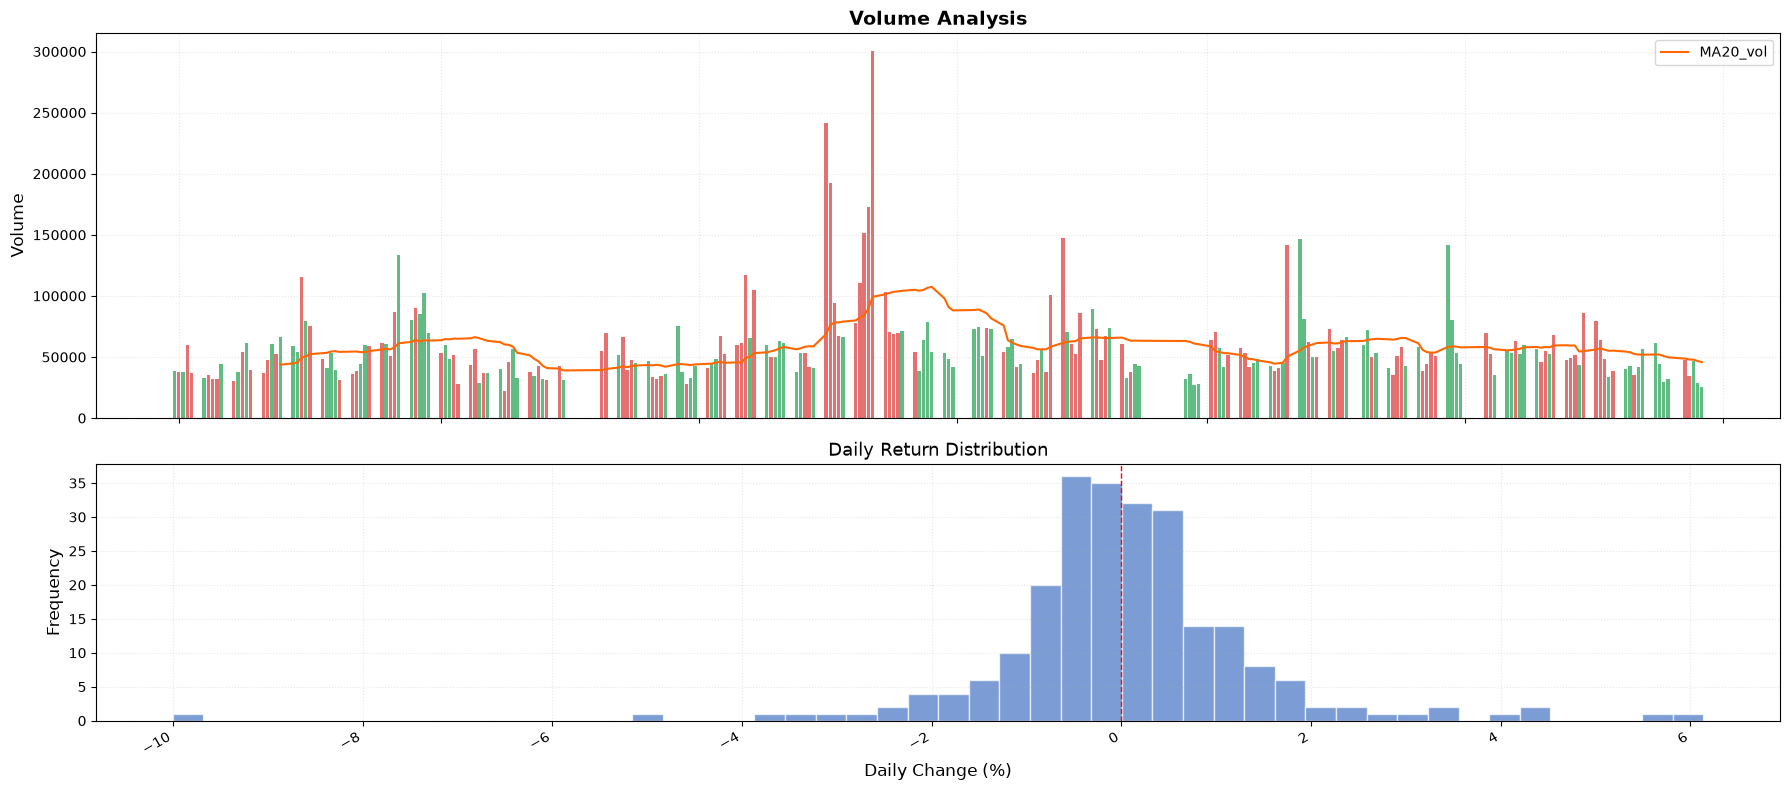

up days: 123 (51.0%)
down days: 118 (49.0%)
avg gain: 0.99%
avg loss: -0.91%


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8),
    gridspec_kw={'height_ratios': [1.5, 1]})

colors = ['#dc3232' if up else '#1ea050' for up in df['is_up']]
ax1.bar(df['date'], df['vol'], color=colors, alpha=0.7, width=0.8)
ax1.set_title('Volume Analysis', fontsize=14, fontweight='bold')
ax1.set_ylabel('Volume', fontsize=12)
ax1.grid(True, alpha=0.3)

df['vol_ma20'] = df['vol'].rolling(20).mean()
ax1.plot(df['date'], df['vol_ma20'], color='#ff6600', lw=1.5, label='MA20_vol')
ax1.legend()

ax2.hist(df['pct_chg'], bins=50, color='#4472c4', alpha=0.7, edgecolor='white')
ax2.axvline(x=0, color='red', ls='--', lw=1)
ax2.set_xlabel('Daily Change (%)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Daily Return Distribution', fontsize=13)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

up_days = df['is_up'].sum()
down_days = len(df) - up_days
print(f"up days: {up_days} ({up_days/len(df)*100:.1f}%)")
print(f"down days: {down_days} ({down_days/len(df)*100:.1f}%)")
print(f"avg gain: {df[df['pct_chg']>0]['pct_chg'].mean():.2f}%")
print(f"avg loss: {df[df['pct_chg']<0]['pct_chg'].mean():.2f}%")

## 7. 价格走势与成交额

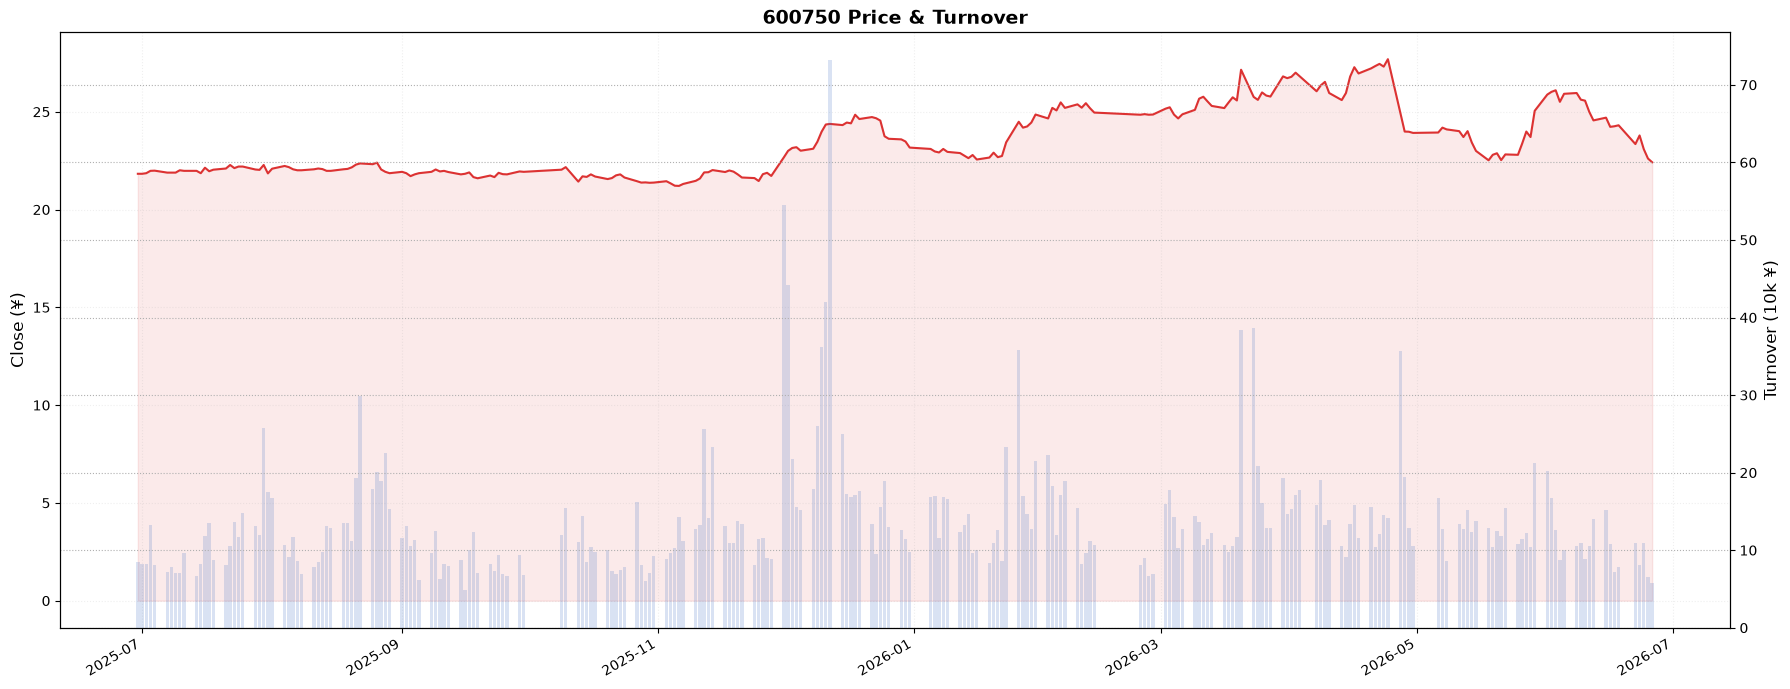

In [8]:
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(df['date'], df['close'], color='#dc3232', lw=1.5, label='close')
ax1.fill_between(df['date'], df['close'], alpha=0.1, color='#dc3232')
ax1.set_ylabel('Close (¥)', fontsize=12)
ax1.set_title('600750 Price & Turnover', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.2)

ax2 = ax1.twinx()
ax2.bar(df['date'], df['amount'] / 1e4, alpha=0.2, color='#4472c4', width=0.8)
ax2.set_ylabel('Turnover (10k ¥)', fontsize=12)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## 总结

- 近一年涨幅约 **+2.7%**（¥21.83 → ¥22.42）
- 最高触及 **¥27.69**（2026-04-24），次日跌停（-10%）后持续回调
- 日均成交量约 **5.8 万手**